### QED-C Prototype Benchmarks - Qiskit Version - with Algorithmix Qubits
The notebook contains a suite of prototype application benchmarks for the IBM Qiskit API, along with the volumetric and the algorithmic qubit (AQ) measurement. 
Configure and run the cell below with the desired execution settings.
Then execute the remaining cells, each containing one prototype benchmark program.

Algorithmic qubits, #AQ = N, can be defined as a side of the largest box of width N and $N^2$ CX gates that can be drawn on the volumetric background, such that every circuit within this box meets the success criteria. In the new #AQ definition, only the number of CX gates in the circuit are tracked as single qubit gates are more accurate in most quantum computer hardware. The success probability of each circuit run on the quantum computer is measured by the Hellinger fidelity computed using the output probability distribution against the ideal output probability distribution. The circuit passes if the measured fidelity is greater than the threshold, which is 0.37. For more details, please visit: https://ionq.com/posts/february-23-2022-algorithmic-qubits

In [11]:
min_qubits=4
max_qubits=4
max_circuits=3
num_shots=1000

backend_id="qasm_simulator"
hub="ibm-q"; group="open"; project="main"
provider_backend = None
exec_options = None

# # *** If using IBMQ hardware, run this once to authenticate
# from qiskit import IBMQ
# IBMQ.save_account('YOUR_API_TOKEN_HERE')

# # *** If you are part of an IBMQ group, set hub, group, and project name here
# hub="YOUR_HUB_NAME"
# group="YOUR_GROUP_NAME"
# project="YOUR_PROJECT_NAME"

# # *** This example shows how to specify the backend using a known "backend_id"
# # Use 'sabre' layout for IBM backends
# exec_options = { "optimization_level":3, "layout_method":'sabre', "routing_method":'sabre' }
# backend_id="ibmq_belem"

# # *** Here's an example of using a typical custom provider backend (e.g. AQT simulator)
# import os
# from qiskit_aqt_provider import AQTProvider
# provider = AQTProvider(os.environ.get('AQT_ACCESS_KEY'))    # get your key from environment
# provider_backend = provider.backends.aqt_qasm_simulator_noise_1
# backend_id="aqt_qasm_simulator_noise_1"

# # An example using IonQ provider
# from qiskit_ionq import IonQProvider
# provider = IonQProvider()   # Be sure to set the QISKIT_IONQ_API_TOKEN environment variable
# provider_backend = provider.get_backend("ionq_qpu")
# backend_id="ionq_qpu"

# # *** Use these lines when running on hardware backend, to limit use of resources
# min_qubits=2
# max_qubits=5
# max_circuits=1
# num_shots=100

### Quantum Fourier Transform - Method 1

Quantum Fourier Transform (1) Benchmark Program - Qiskit
... execution starting at May 09, 2024 18:06:39 UTC
************
Executing [3] circuits with num_qubits = 4
... number of gates, depth = 29, 22
************
Average Circuit Algorithmic Depth, ξ (xi) for the 4 qubit group = 23, 0.474
Average Normalized Transpiled Depth, ξ (xi), 2q gates for the 4 qubit group = 58, 0.346, 24.0
Average Creation, Elapsed, Execution Time for the 4 qubit group = 0.003, 0.144, 0.02 secs
Average Transpiling, Validating, Running Times for group 4 = 0.001, 0.001, 0.001 secs
Average Hellinger, Normalized Fidelity for the 4 qubit group = 0.903, 0.897

... execution complete at May 09, 2024 18:06:40 UTC in 0.334 secs

Sample Circuit:
             ░ ┌──────┐ ░  ┌───────┐  ░ ┌──────────┐ ░ ┌─┐         
q76_0: ──────░─┤0     ├─░──┤ Rz(π) ├──░─┤0         ├─░─┤M├─────────
             ░ │      │ ░ ┌┴───────┴┐ ░ │          │ ░ └╥┘┌─┐      
q76_1: ──────░─┤1     ├─░─┤ Rz(π/2) ├─░─┤1         ├─░──╫─┤M├──────
        

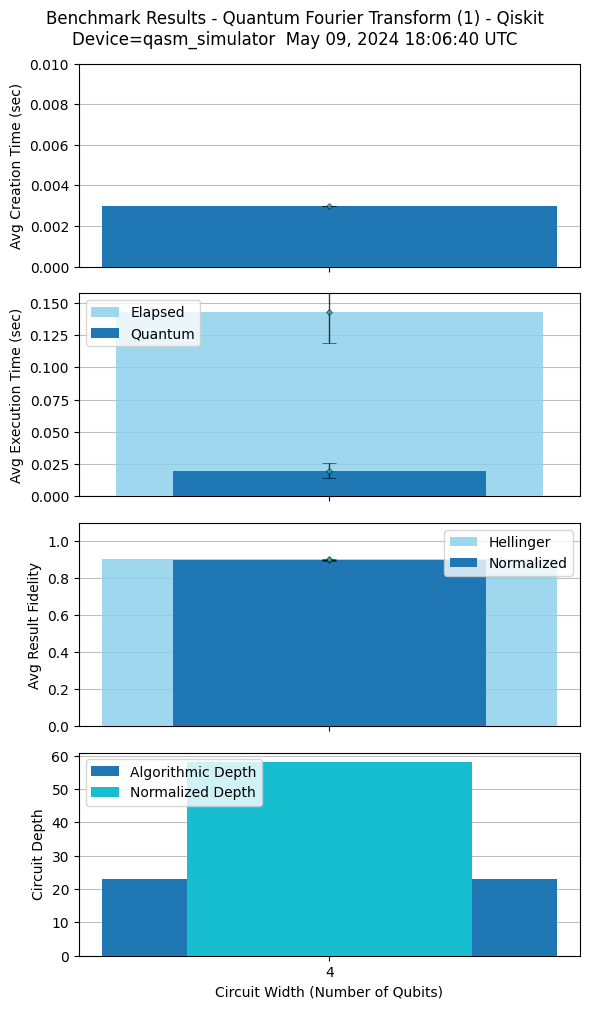

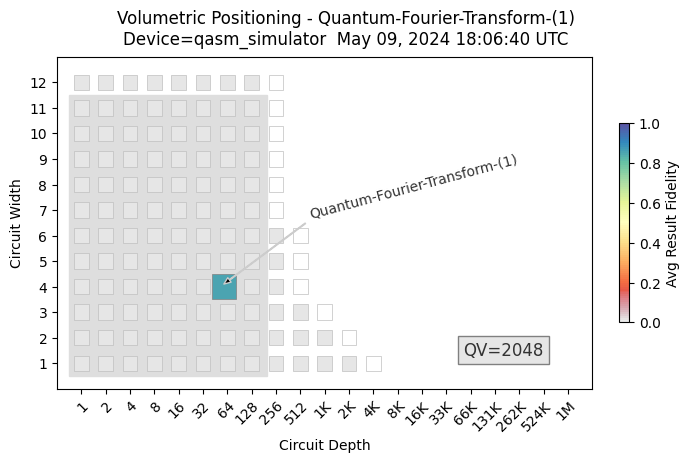

In [12]:
#%run quantum-fourier-transform/qiskit/qft_benchmark.py
import sys
sys.path.insert(1, "quantum-fourier-transform/qiskit")
import qft_benchmark
qft_benchmark.run(min_qubits=min_qubits, max_qubits=max_qubits, max_circuits=max_circuits, num_shots=num_shots,
                method=1,
                backend_id=backend_id, provider_backend=provider_backend,
                hub=hub, group=group, project=project, exec_options=exec_options)

### Phase Estimation

Phase Estimation Benchmark Program - Qiskit
... execution starting at May 09, 2024 18:06:42 UTC
************
Executing [3] circuits with num_qubits = 4
************
Average Circuit Algorithmic Depth, ξ (xi) for the 4 qubit group = 27, 0.353
Average Normalized Transpiled Depth, ξ (xi), 2q gates for the 4 qubit group = 30, 0.295, 11.333
Average Creation, Elapsed, Execution Time for the 4 qubit group = 0.008, 0.116, 0.009 secs
Average Transpiling, Validating, Running Times for group 4 = 0.001, 0.001, 0.001 secs
Average Hellinger, Normalized Fidelity for the 4 qubit group = 0.965, 0.96

... execution complete at May 09, 2024 18:06:42 UTC in 0.322 secs

Sample Circuit:
        ┌───┐ ░                       ░ ┌──────────┐ ░ ┌─┐      
q137_0: ┤ H ├─░──────────────────■────░─┤0         ├─░─┤M├──────
        ├───┤ ░                  │    ░ │          │ ░ └╥┘┌─┐   
q137_1: ┤ H ├─░───────────■──────┼────░─┤1 inv_qft ├─░──╫─┤M├───
        ├───┤ ░           │      │    ░ │          │ ░  ║ └╥┘┌─┐
q1

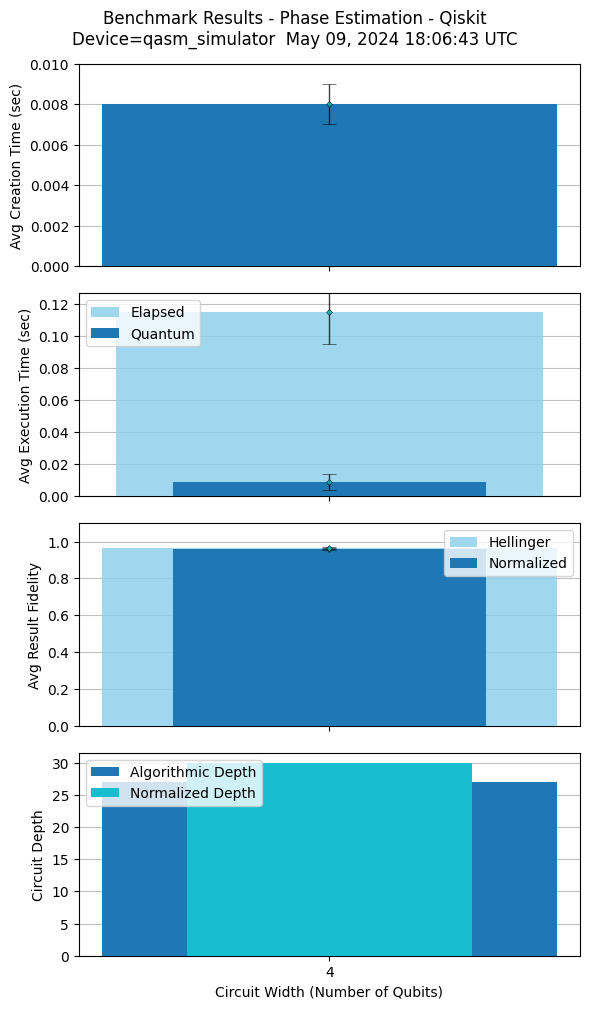

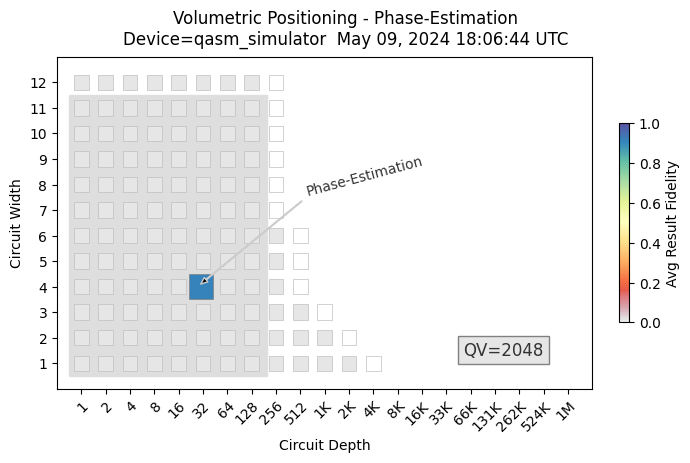

In [13]:
#%run phase-estimation/qiskit/pe_benchmark.py
import sys
sys.path.insert(1, "phase-estimation/qiskit")
import pe_benchmark
pe_benchmark.run(min_qubits=min_qubits, max_qubits=max_qubits, max_circuits=max_circuits, num_shots=num_shots,
                backend_id=backend_id, provider_backend=provider_backend,
                hub=hub, group=group, project=project, exec_options=exec_options)

### Amplitude Estimation

In [14]:
#%run amplitude-estimation/qiskit/ae_benchmark.py
import sys
sys.path.insert(1, "amplitude-estimation/qiskit")
import ae_benchmark
ae_benchmark.run(min_qubits=min_qubits, max_qubits=max_qubits, max_circuits=max_circuits, num_shots=num_shots,
                backend_id=backend_id, provider_backend=provider_backend,
                hub=hub, group=group, project=project, exec_options=exec_options)

Amplitude Estimation Benchmark Program - Qiskit
... execution starting at May 09, 2024 18:06:46 UTC
************
Executing [3] circuits with num_qubits = 4


/home/sonny/Projects/QC-App-Oriented-Benchmarks/amplitude-estimation/qiskit/ae_benchmark.py:92: RuntimeWarning: invalid value encountered in arcsin
  theta = 2 * np.arcsin(np.sqrt(a))


CircuitError: "Invalid param type <class 'numpy.ndarray'> for gate ry."

### Monte Carlo

Monte Carlo Sampling (2) Benchmark Program - Qiskit
... execution starting at May 09, 2024 18:07:02 UTC
************
Executing [3] circuits with num_qubits = 4
************
Average Circuit Algorithmic Depth, ξ (xi) for the 4 qubit group = 202, 0.398
Average Normalized Transpiled Depth, ξ (xi), 2q gates for the 4 qubit group = 208, 0.372, 96.0
Average Creation, Elapsed, Execution Time for the 4 qubit group = 0.035, 0.286, 0.024 secs
Average Transpiling, Validating, Running Times for group 4 = 0.001, 0.001, 0.001 secs
Average Hellinger, Normalized Fidelity for the 4 qubit group = 0.8, 0.6

... execution complete at May 09, 2024 18:07:03 UTC in 0.785 secs

Sample Circuit:
        ┌────┐┌──────┐┌──────┐┌──────┐ ░              ░       
q221_0: ┤0   ├┤1     ├┤1     ├┤1     ├─░──────────────░───────
        │  A ││      ││      ││      │ ░              ░       
q221_1: ┤1   ├┤2     ├┤2 c_Q ├┤2 c_Q ├─░──────────────░───────
        ├───┬┘│  c_Q ││      ││      │ ░ ┌──────────┐ ░ ┌─┐   
q222_0:

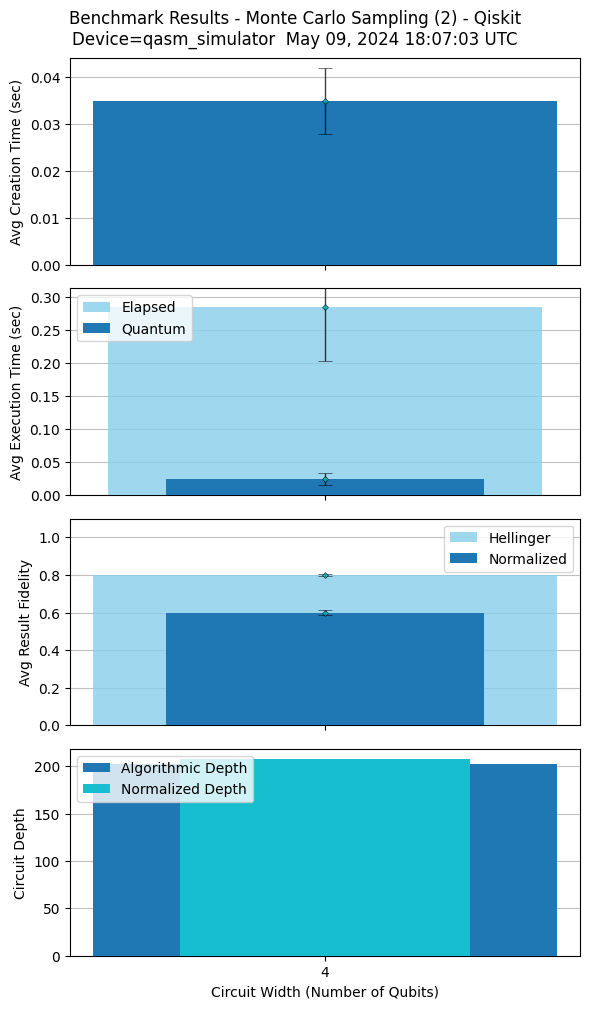

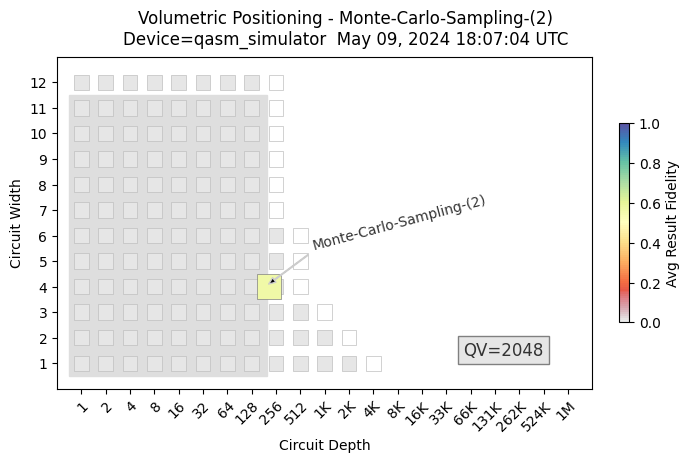

In [15]:
#%run monte-carlo/qiskit/mc_benchmark.py
import sys
sys.path.insert(1, "monte-carlo/qiskit")
import mc_benchmark
mc_benchmark.run(min_qubits=min_qubits, max_qubits=max_qubits, max_circuits=max_circuits, num_shots=num_shots,
                backend_id=backend_id, provider_backend=provider_backend,
                hub=hub, group=group, project=project, exec_options=exec_options)

## Difference between the Hellinger fidelity and the Polarization fidelity

Note that there is a difference between Hellinger Fidelity and the "Result Fidelity", which is polarization fidelity,  especially in algorithms with output states that are not in the computatiobal basis (the output distribution does not concentrate on just one bitstring). In the current benchmark suite, such a difference is shown in the amplitude estimation and the Monte Carlo algorithms. This could be understand by looking at the definition of the Hellinger fidelity and the polarization fidelity. 

The Hellinger fidelity is defined as
\begin{equation}
    F_s(P_{ideal}, P_{output})=\left(\sum_x{\sqrt{P_{output}(x)P_{ideal}(x)}}\right)^2
\end{equation}
and the polarization fidelity is defined as
\begin{equation}
    F(P_{ideal}, P_{output})=\frac{F_s(P_{ideal}, P_{output})-F_s(P_{ideal}, P_{uni})}{1-F_s(P_{ideal}, P_{uni})}
\end{equation}
in which $P_{uni}$ is the uniform distribution, and $P_{uni}(x)=1/2^n \forall x$, in which $n$ is the total number of qubits being measured.  


As one could see, the polarization fidelity is defined as to subtract the uniform distribution from the Hellinger fidelity, and normalize it so that it is between 0 and 1. It is an open research question about which fidelity measures the algorithm performance more accurately. As the number of qubit increases, $F_s(P_{ideal}, P_{uni})$ becomes exponentially small so that these two fidelities agree with each other in the large qubit number limit. With a small number of qubits, the Hellinger fidelity is usually higer than the polarization fidelity, especially for circuits whose output states are not in the computational basis. This could be understood by the following example. 

Consider a circuit with 2 qubits and the ideal distribution is {'01':1.0}. In this case, the ideal output state is in the computational basis (all population in one bitstring). When using a depolarization noise model with error rate of 25%, the output distribution becomes {'00':0.0625, '01':0.8125, '10':0.0625, '11':0.0625}, and then the Helliger fidelity and the polarization fidelity are the same

\begin{equation}
    F_s=0.8125, F=0.8125
\end{equation}

Then consider another circuit with 2 qubits and the ideal distribution is {'01':0.5, '10':0.5}, in which the output state is not in the computational basis (population spreads out to multiple bitstrings). When using a depolarization noise model with error rate of 25%, the output distribution becomes {'00':0.0625, '01':0.4375, '10':0.4375, '11':0.0625}, and then the Helliger fidelity and the polarization fidelity are

\begin{equation}
    F_s=0.875, F=0.778
\end{equation}
and in this case the Hellinger fidelity is higher than the polarization fidelity. 

### Hamiltonian Simulation

In [16]:
#%run hamiltonian-simulation/qiskit/hamiltonian_simulation_benchmark.py
import sys
sys.path.insert(1, "hamiltonian-simulation/qiskit")
import hamiltonian_simulation_benchmark
hamiltonian_simulation_benchmark.run(min_qubits=min_qubits, max_qubits=max_qubits,
                max_circuits=max_circuits, num_shots=num_shots,
                backend_id=backend_id, provider_backend=provider_backend,
                hub=hub, group=group, project=project, exec_options=exec_options)

ModuleNotFoundError: No module named 'tket_optimiser'

### VQE Ansatz - Method 1

VQE Simulation (1) Benchmark Program - Qiskit
... execution starting at May 09, 2024 18:07:19 UTC
************
Executing [3] circuits with num_qubits = 4
************
Average Circuit Algorithmic Depth, ξ (xi) for the 4 qubit group = 5, 0.0
Average Normalized Transpiled Depth, ξ (xi), 2q gates for the 4 qubit group = 76, 0.533, 56.0
Average Creation, Elapsed, Execution Time for the 4 qubit group = 0.175, 0.207, 0.017 secs
Average Transpiling, Validating, Running Times for group 4 = 0.001, 0.001, 0.001 secs
Average Hellinger, Normalized Fidelity for the 4 qubit group = 0.853, 0.822

... execution complete at May 09, 2024 18:07:19 UTC in 0.528 secs

Sample Circuit:
        ┌─────┐┌────────────────────┐┌────────────────────┐»
q248_0: ┤0    ├┤0                   ├┤0                   ├»
        │     ││                    ││                    │»
q248_1: ┤1    ├┤1                   ├┤1                   ├»
        │  Hf ││  Cluster Op (0, 1) ││  Cluster Op (2, 3) │»
q248_2: ┤2    ├┤2       

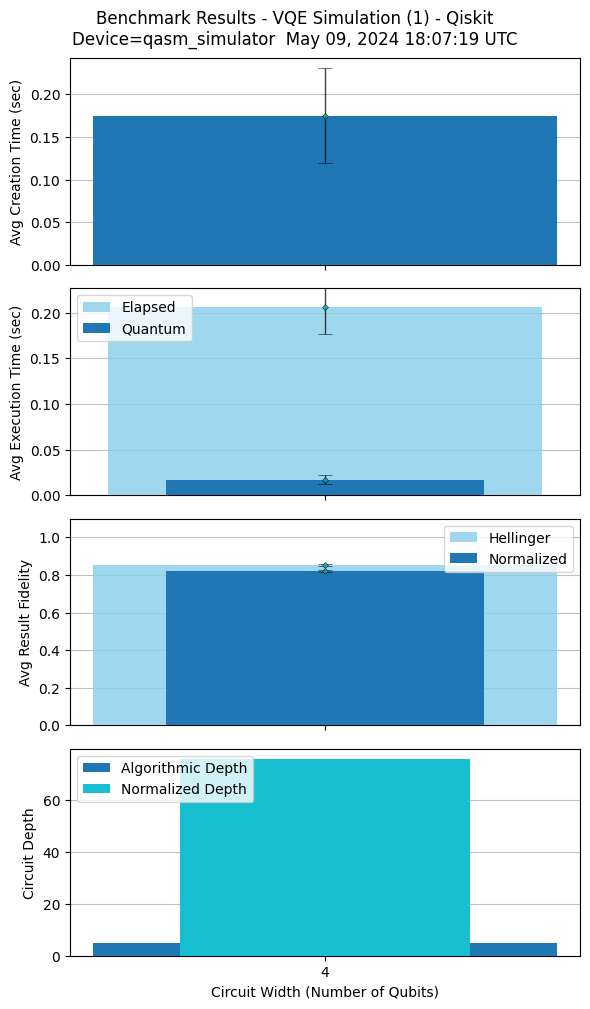

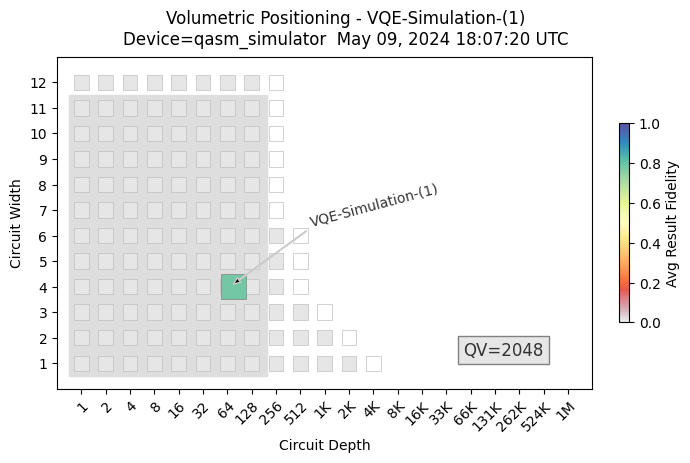

In [17]:
#%run vqe/qiskit/vqe_benchmark.py
import sys
sys.path.insert(1, "vqe/qiskit")
import vqe_benchmark
vqe_num_shots=4098
vqe_benchmark.run(min_qubits=min_qubits, max_qubits=max_qubits, max_circuits=max_circuits, num_shots=vqe_num_shots,
                method=1,
                backend_id=backend_id, provider_backend=provider_backend,
                hub=hub, group=group, project=project, exec_options=exec_options)

### All Applications - Algorithmic Qubits - Hellinger Fidelity

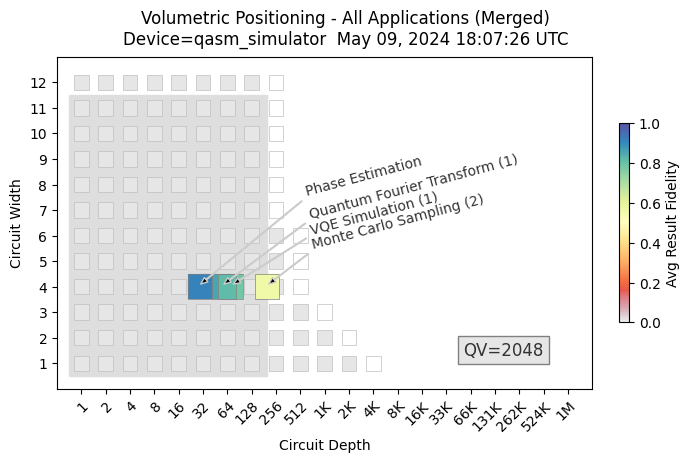

In [18]:
import sys
sys.path.insert(1, "_common")
import metrics


metrics.plot_all_app_metrics(backend_id, do_all_plots=False, include_apps=apps)

### All Applications - Algorithmic Qubits - Normalized Result Fidelity

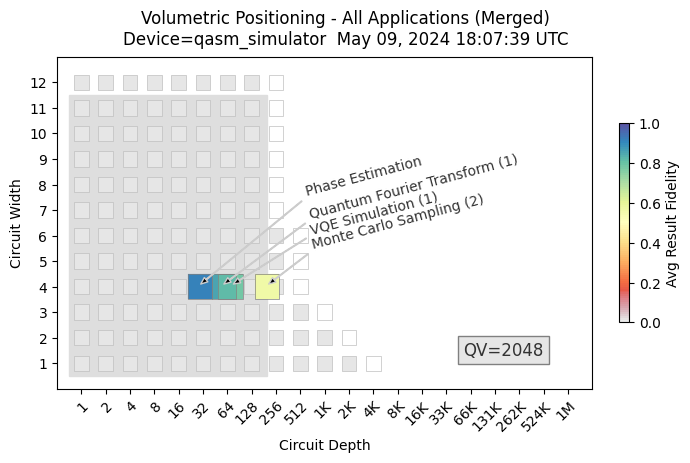

In [19]:
import sys
sys.path.insert(1, "_common")
import metrics

apps = [ "Quantum Fourier Transform (1)", "Phase Estimation", "Amplitude Estimation", "Monte Carlo Sampling (2)", "VQE Simulation (1)",  "Hamiltonian Simulation" ]

metrics.plot_all_app_metrics(backend_id, do_all_plots=False, include_apps=apps, score_metric='avg_fidelities')